In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from LinearRegression.LinReg import LinearRegression

%matplotlib widget

In [ ]:
x1 = np.linspace(-20, 20, 200)
x2 = np.random.uniform(0, 50, 200)
X = np.column_stack((x1, x2))

n = X.shape[0]
n_val = int(n * 0.2)

idx = np.random.permutation(n)
val_idx, train_idx = idx[:n_val], idx[n_val:]

X_val, X_train = X[val_idx, :], X[train_idx, :]

y_val = 5 + 2 * X_val[:, 0] - 3 * X_val[:, 1]

y_train_true = 5 + 2 * X_train[:, 0] - 3 * X_train[:, 1]
noise = np.random.normal(0, 3, y_train_true.shape[0])
y_train = y_train_true + noise

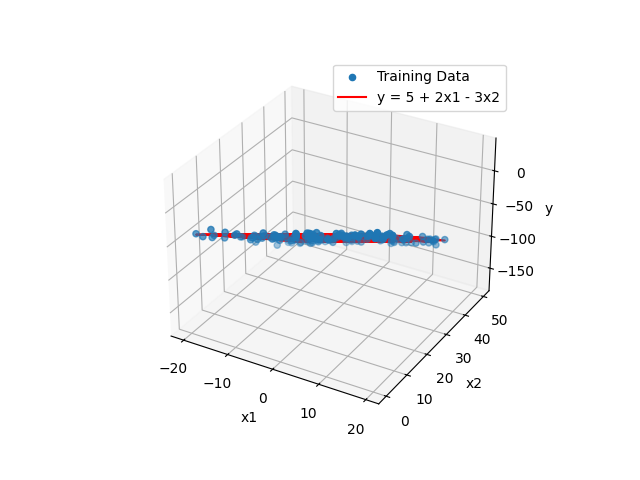

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection = '3d')
ax.scatter(X_train[:, 0], X_train[:, 1], y_train, label = 'Training Data')
ax.plot(X_train[:, 0], X_train[:, 1], y_train_true, label = 'y = 5 + 2x1 - 3x2', color = 'red')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
plt.legend()

In [ ]:
#Training the 5 different types of ways HOML outlines you can determine the values for Theta for Linear Regression
lin_reg = LinearRegression()
theta_methods = ['normal', 'pseudoinverse', 'batch', 'minibatch', 'stochastic']
gd_methods = ['batch', 'minibatch', 'stochastic']

predicted_values = dict()
thetas = dict()
theta_histories = dict()

for method in theta_methods:
    lin_reg.fit(X_train, y_train, type = method)
    predicted_values[method] = lin_reg.predict(X_val)
    thetas[method] = lin_reg._theta 

    if method in gd_methods:
        theta_histories[method] = lin_reg._theta_history

Initialized a Linear Regression Model


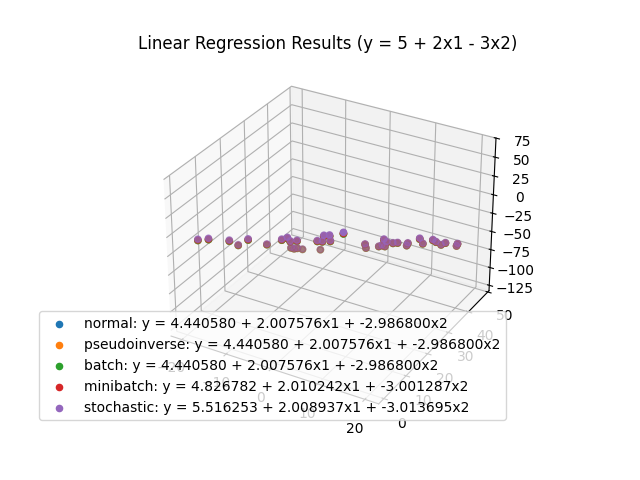

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection = '3d')
ax.set_title('Linear Regression Results (y = 5 + 2x1 - 3x2)')

for method in theta_methods:
    y_pred = predicted_values[method]
    theta0 = thetas[method][0]
    theta1 = thetas[method][1]
    theta2 = thetas[method][2]
    ax.scatter(X_val[:, 0], X_val[:, 1], y_pred, label = f'{method}: y = {theta0:2f} + {theta1:2f}x1 + {theta2:2f}x2')

plt.legend(loc = 'lower right')
plt.show()